 ## STL symmetry - UNet + K-Fold + GradCAM

In [1]:
import os
import json
import time
import datetime as dt
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

import tensorflow as tf
from sklearn.model_selection import StratifiedKFold
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    balanced_accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, ConfusionMatrixDisplay, precision_score, recall_score,
    f1_score, cohen_kappa_score,
)
os.environ["CUDA_VISIBLE_DEVICES"] = "1"

### Nota important:
# He eliminat ISIC_0028189 del conjunt de train, perquè era corrupta.

2026-06-22 20:34:13.820177: I tensorflow/stream_executor/platform/default/dso_loader.cc:48] Successfully opened dynamic library libcudart.so.10.1


In [2]:
train_csv  = "/home/marc/MARIADELMAR_EXPERIMENTS/onehot_files/train_onehot.csv"
val_csv    = "/home/marc/MARIADELMAR_EXPERIMENTS/onehot_files/val_onehot.csv"
test_csv   = "/home/marc/MARIADELMAR_EXPERIMENTS/onehot_files/test_onehot.csv"
images_dir = "/home/marc/MARIADELMAR_EXPERIMENTS/dataverse_files/images"

IMG_SIZE    = (256, 256)   # UNet usa 256x256 (propio de la arquitectura)
BATCH_SIZE  = 16           # autoencoder: el decoder dobla la memoria, batch 16 como en disease
NUM_CLASSES = 3
N_FOLDS     = 5
TASK_NAME   = "symmetry"
class_names = ["2_ejes", "1_eje", "asimetrica"]   # clases de symmetry


EPOCHS  = 60
LR_INIT = 5e-4

_exp_name = f"exp_{dt.datetime.now():%Y-%m-%d_%H-%M}_{TASK_NAME}_{N_FOLDS}fold"
EXP_DIR = Path("/home/marc/MARIADELMAR_EXPERIMENTS/STL_Symmetry_experimentos/UNet_STL") / _exp_name
EXP_DIR.mkdir(parents=True, exist_ok=True)
print(f"Experimento STL ({TASK_NAME}) en: {EXP_DIR.resolve()}")

Experimento STL (symmetry) en: /home/marc/MARIADELMAR_EXPERIMENTS/STL_Symmetry_experimentos/UNet_STL/exp_2026-06-22_20-34_symmetry_5fold


In [3]:
df_train = pd.read_csv(train_csv)
df_val   = pd.read_csv(val_csv)
df_test  = pd.read_csv(test_csv)

# CSV de symmetry 
df_sym   = pd.read_csv("/home/marc/MARIADELMAR_EXPERIMENTS/ham10000_shape_symmetry_ALL.csv")

print(f"CSVs - train: {len(df_train)}  val: {len(df_val)}  test: {len(df_test)}")
print(f"Symmetry CSV - total: {len(df_sym)}")

# Renombrar columna y merge con cada split
df_sym = df_sym.rename(columns={"image": "image_id"})
df_sym = df_sym[["image_id", "shape_symmetry"]]


def merge_with_sym(df, name):
    before = len(df)
    merged = df.merge(df_sym, on="image_id", how="inner")
    lost   = before - len(merged)
    if lost > 0:
        print(f"  [WARN] {name}: perdidas {lost} imágenes sin entrada en symmetry CSV")
    else:
        print(f"  {name}: merge OK, 0 imágenes perdidas")
    return merged


print("\nMerge con CSV de symmetry:")
df_train = merge_with_sym(df_train, "train")
df_val   = merge_with_sym(df_val,   "val")
df_test  = merge_with_sym(df_test,  "test")

# Path completo a las imágenes
for df in (df_train, df_val, df_test):
    df["filepath"] = df["image_id"].apply(lambda x: os.path.join(images_dir, f"{x}.jpg"))


# Etiquetas de symmetry (one-hot)
def to_onehot_sym(df):
    y = np.zeros((len(df), NUM_CLASSES), dtype="float32")
    y[np.arange(len(df)), df["shape_symmetry"].values] = 1.0
    return y


y_train = to_onehot_sym(df_train)
y_val   = to_onehot_sym(df_val)
y_test  = to_onehot_sym(df_test)

# Combinar train+val para KFold
df_trainval    = pd.concat([df_train, df_val], ignore_index=True)
y_trainval     = np.concatenate([y_train, y_val], axis=0)
y_trainval_int = np.argmax(y_trainval, axis=1)
y_test_int     = np.argmax(y_test, axis=1)

print("\n" + "="*60)
print(f"DISTRIBUCIÓN DE ETIQUETAS - tarea: {TASK_NAME}")
print("="*60)
for i, c in enumerate(class_names):
    n = (y_trainval_int == i).sum()
    print(f"  {c:<12} {n:>5}  ({100*n/len(y_trainval_int):.1f}%)")
print(f"\nTest set fijo: {len(df_test)} imágenes")

# Class weights balanceados
cw = compute_class_weight(class_weight="balanced",
                          classes=np.arange(NUM_CLASSES),
                          y=y_trainval_int)
CW = tf.constant(cw, dtype=tf.float32)
class_weight_dict = {i: float(cw[i]) for i in range(NUM_CLASSES)}
print(f"\nClass weights: {cw.round(3)}")

CSVs — train: 6008  val: 2003  test: 2003
Symmetry CSV — total: 10015

Merge con CSV de symmetry:
  train: merge OK, 0 imágenes perdidas
  val: merge OK, 0 imágenes perdidas
  test: merge OK, 0 imágenes perdidas

DISTRIBUCIÓN DE ETIQUETAS — tarea: symmetry
  2_ejes        4785  (59.7%)
  1_eje         2468  (30.8%)
  asimetrica     758  (9.5%)

Test set fijo: 2003 imágenes


2026-06-22 20:34:14.897992: I tensorflow/stream_executor/platform/default/dso_loader.cc:48] Successfully opened dynamic library libcuda.so.1



Class weights: [0.558 1.082 3.523]


2026-06-22 20:34:14.925106: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1716] Found device 0 with properties: 
pciBusID: 0000:06:00.0 name: GeForce GTX 1080 Ti computeCapability: 6.1
coreClock: 1.582GHz coreCount: 28 deviceMemorySize: 10.92GiB deviceMemoryBandwidth: 451.17GiB/s
2026-06-22 20:34:14.925147: I tensorflow/stream_executor/platform/default/dso_loader.cc:48] Successfully opened dynamic library libcudart.so.10.1
2026-06-22 20:34:14.926892: I tensorflow/stream_executor/platform/default/dso_loader.cc:48] Successfully opened dynamic library libcublas.so.10
2026-06-22 20:34:14.928466: I tensorflow/stream_executor/platform/default/dso_loader.cc:48] Successfully opened dynamic library libcufft.so.10
2026-06-22 20:34:14.928740: I tensorflow/stream_executor/platform/default/dso_loader.cc:48] Successfully opened dynamic library libcurand.so.10
2026-06-22 20:34:14.930503: I tensorflow/stream_executor/platform/default/dso_loader.cc:48] Successfully opened dynamic library libcusolv

In [4]:
def load_image(filepath, y):
    img = tf.io.read_file(filepath)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32) / 255.0
    # Doble target: la propia imagen (reconstruccion) y la etiqueta (clasificacion)
    return img, {"reconstruction_output": img, "head_sym": y}


def load_image_aug(filepath, y):
    img = tf.io.read_file(filepath)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32)
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_flip_up_down(img)
    img = tf.image.random_brightness(img, max_delta=0.2)
    img = tf.image.random_contrast(img, lower=0.8, upper=1.2)
    img = tf.clip_by_value(img, 0.0, 255.0)
    img = img / 255.0
    # El objetivo de reconstruccion es la misma imagen (aumentada) que entra a la red
    return img, {"reconstruction_output": img, "head_sym": y}


def make_dataset(filepaths, y, training=False):
    ds = tf.data.Dataset.from_tensor_slices((filepaths, y))
    if training:
        ds = ds.shuffle(buffer_size=len(filepaths), reshuffle_each_iteration=True)
    ds = ds.map(load_image_aug if training else load_image, num_parallel_calls=15)
    ds = ds.batch(BATCH_SIZE).prefetch(50)
    return ds


# Sanity check: un batch del test_ds
test_ds = make_dataset(
    df_test["filepath"].values,
    y_test,
    training=False,
)

print("Sanity check: un batch del test_ds")
for imgs, targets in test_ds.take(1):
    print(f"  imagen: shape={imgs.shape}  dtype={imgs.dtype}  "
          f"min={imgs.numpy().min():.2f}  max={imgs.numpy().max():.2f}")
    print(f"  reconstruction_output: shape={targets['reconstruction_output'].shape}")
    print(f"  head_sym: shape={targets['head_sym'].shape}  (esperado: (BS, 3))")

Sanity check: un batch del test_ds
  imagen: shape=(16, 256, 256, 3)  dtype=<dtype: 'float32'>  min=0.03  max=1.00
  reconstruction_output: shape=(16, 256, 256, 3)
  head_sym: shape=(16, 3)  (esperado: (BS, 3))


In [5]:
def encoder_block(inputs, num_filters):
    x = tf.keras.layers.Conv2D(num_filters, 3, activation="relu", padding="same",
                               kernel_initializer="he_normal")(inputs)
    x = tf.keras.layers.Conv2D(num_filters, 3, activation="relu", padding="same",
                               kernel_initializer="he_normal")(x)
    x = tf.keras.layers.BatchNormalization()(x)
    p = tf.keras.layers.MaxPool2D(pool_size=(2, 2), strides=2)(x)
    return x, p


def decoder_block(inputs, skip_features, num_filters):
    up = tf.keras.layers.UpSampling2D(size=(2, 2))(inputs)
    x  = tf.keras.layers.Conv2D(num_filters, 2, activation="relu", padding="same",
                                kernel_initializer="he_normal")(up)
    x = tf.keras.layers.concatenate([skip_features, x], axis=3)
    x = tf.keras.layers.Conv2D(num_filters, 3, activation="relu", padding="same",
                               kernel_initializer="he_normal")(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Conv2D(num_filters, 3, activation="relu", padding="same",
                               kernel_initializer="he_normal")(x)
    x = tf.keras.layers.BatchNormalization()(x)
    return x


def build_model():
    inputs = tf.keras.layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3),
                                   name="input_image")

    # Codificador
    c1, p1 = encoder_block(inputs, 64)
    c2, p2 = encoder_block(p1, 128)
    c3, p3 = encoder_block(p2, 256)
    c4, p4 = encoder_block(p3, 512)

    # Cuello de botella
    b1 = tf.keras.layers.Conv2D(1024, 3, activation="relu", padding="same",
                                kernel_initializer="he_normal")(p4)
    b1 = tf.keras.layers.BatchNormalization()(b1)
    b1 = tf.keras.layers.Conv2D(1024, 3, activation="relu", padding="same",
                                kernel_initializer="he_normal",
                                name="bottleneck_conv")(b1)   # capa de activacion para Grad-CAM
    b1 = tf.keras.layers.BatchNormalization(name="bottleneck_bn")(b1)

    # Decodificador (se entrena: reconstruye la imagen de entrada)
    e1 = decoder_block(b1, c4, 512)
    e2 = decoder_block(e1, c3, 256)
    e3 = decoder_block(e2, c2, 128)
    e4 = decoder_block(e3, c1, 64)

    final_recon = tf.keras.layers.Conv2D(64, 3, activation="relu", padding="same",
                                         kernel_initializer="he_normal")(e4)
    final_recon = tf.keras.layers.BatchNormalization()(final_recon)
    reconstruction_output = tf.keras.layers.Conv2D(3, 1, activation="relu", padding="same",
                                                   name="reconstruction_output")(final_recon)

    # Clasificacion 
    x = tf.keras.layers.GlobalAveragePooling2D(name="gap")(b1)
    shared = tf.keras.layers.Dense(256, activation="relu", name="shared_dense")(x)
    shared = tf.keras.layers.Dropout(0.3, name="shared_dropout")(shared)
    out = tf.keras.layers.Dense(NUM_CLASSES, activation="softmax", name="head_sym")(shared)

    model = tf.keras.Model(
        inputs=inputs,
        outputs=[reconstruction_output, out],
        name="STL_UNet_sym_autoencoder",
    )
    return model, None


_tmp_backbone, _ = build_model()
_tmp_backbone.summary()
tf.keras.utils.plot_model(
    _tmp_backbone,
    to_file=str(EXP_DIR / "00_model_architecture.png"),
    show_shapes=True, show_layer_names=True, dpi=150,
)
del _tmp_backbone
tf.keras.backend.clear_session()

Model: "STL_UNet_sym_autoencoder"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_image (InputLayer)        [(None, 256, 256, 3) 0                                            
__________________________________________________________________________________________________
conv2d (Conv2D)                 (None, 256, 256, 64) 1792        input_image[0][0]                
__________________________________________________________________________________________________
conv2d_1 (Conv2D)               (None, 256, 256, 64) 36928       conv2d[0][0]                     
__________________________________________________________________________________________________
batch_normalization (BatchNorma (None, 256, 256, 64) 256         conv2d_1[0][0]                   
___________________________________________________________________________

In [6]:
def fit_stl(model, train_ds, val_ds, epochs,
            patience_es=7, patience_lr=3, factor_lr=0.5, min_lr=1e-7,
            verbose=True):
    # Con dos salidas (reconstruccion + clasificacion) Keras no admite class_weight.
    # El balanceo de clases se aplica con sample_weight (ver make_dataset_weighted).
    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=patience_es,
            min_delta=0.005,
            restore_best_weights=True,
            verbose=1,
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=factor_lr,
            patience=patience_lr,
            min_lr=min_lr,
            verbose=1,
        ),
    ]

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=epochs,
        callbacks=callbacks,
        verbose=2 if verbose else 0,
    )

    return history.history

In [7]:
def make_dataset_weighted(filepaths, y, class_weight_arr, training=False):
    
    y_int  = np.argmax(y, axis=1)
    sw_sym = class_weight_arr[y_int].astype("float32")

    def _load(filepath, label, sw, training_flag):
        img = tf.io.read_file(filepath)
        img = tf.image.decode_image(img, channels=3, expand_animations=False)
        img = tf.image.resize(img, IMG_SIZE)
        img = tf.cast(img, tf.float32)
        if training_flag:
            img = tf.image.random_flip_left_right(img)
            img = tf.image.random_flip_up_down(img)
            img = tf.image.random_brightness(img, max_delta=0.2)
            img = tf.image.random_contrast(img, lower=0.8, upper=1.2)
            img = tf.clip_by_value(img, 0.0, 255.0)
        img = img / 255.0
        targets  = {"reconstruction_output": img, "head_sym": label}
        sample_w = {"reconstruction_output": tf.constant(1.0, dtype=tf.float32),
                    "head_sym": sw}
        return img, targets, sample_w

    ds = tf.data.Dataset.from_tensor_slices((filepaths, y, sw_sym))
    if training:
        ds = ds.shuffle(buffer_size=len(filepaths), reshuffle_each_iteration=True)
    ds = ds.map(lambda f, l, s: _load(f, l, s, training), num_parallel_calls=15)
    ds = ds.batch(BATCH_SIZE).prefetch(50)
    return ds


def train_one_fold(fold_idx, train_idx, val_idx, fold_dir):
    
    fold_dir.mkdir(exist_ok=True)
    print(f"\n{'='*70}\nFOLD {fold_idx}/{N_FOLDS}  (U-Net {TASK_NAME} autoencoder, desde cero)\n{'='*70}")

    df_tr = df_trainval.iloc[train_idx].reset_index(drop=True)
    df_vl = df_trainval.iloc[val_idx].reset_index(drop=True)
    y_tr  = to_onehot_sym(df_tr)
    y_vl  = to_onehot_sym(df_vl)

    print(f"  train={len(df_tr)}  val={len(df_vl)}  test(fijo)={len(df_test)}")

    # Class weights del fold (se aplican via sample_weight)
    y_tr_int = np.argmax(y_tr, axis=1)
    cw_fold = compute_class_weight(
        class_weight="balanced",
        classes=np.arange(NUM_CLASSES),
        y=y_tr_int,
    )
    print(f"  Class weights: {cw_fold.round(3)}")

    train_ds = make_dataset_weighted(df_tr["filepath"].values, y_tr, cw_fold, training=True)
    val_ds   = make_dataset_weighted(df_vl["filepath"].values, y_vl, cw_fold, training=False)

    # Construir y compilar modelo (dos perdidas)
    model, _ = build_model()
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=LR_INIT),
        loss={
            "reconstruction_output": "mse",
            "head_sym":              "categorical_crossentropy",
        },
        loss_weights={
            "reconstruction_output": 0.2,
            "head_sym":              0.8,
        },
        metrics={
            "head_sym": "accuracy",
        },
    )

    # Entrenamiento unico (red completa desde cero, sin transfer learning)
    print(f"\n--- Entrenamiento U-Net autoencoder (LR={LR_INIT}, max_epochs={EPOCHS}) ---")
    t0 = time.time()
    history = fit_stl(
        model, train_ds, val_ds,
        epochs=EPOCHS,
        patience_es=7, patience_lr=3,
    )
    t_train = time.time() - t0

    pd.DataFrame(history).to_csv(fold_dir / "history.csv", index=False)

    # Plot de history (loss total + accuracy de clasificacion)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(history["loss"],     label="train")
    axes[0].plot(history["val_loss"], label="val", linestyle="--")
    axes[0].set_xlabel("epoch"); axes[0].set_ylabel("loss total")
    axes[0].set_title(f"Fold {fold_idx} - Loss total (recon + clasif)")
    axes[0].legend(); axes[0].grid(alpha=0.3)

    acc_key     = "head_sym_accuracy"
    val_acc_key = "val_head_sym_accuracy"
    if acc_key in history:
        axes[1].plot(history[acc_key],     label="train")
        axes[1].plot(history[val_acc_key], label="val", linestyle="--")
    axes[1].set_xlabel("epoch"); axes[1].set_ylabel("accuracy")
    axes[1].set_title(f"Fold {fold_idx} - Accuracy clasificacion")
    axes[1].legend(); axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(fold_dir / "training_curves.png", dpi=100)
    plt.show()

    # Evaluacion sobre test fijo
    print(f"\n--- Evaluacion sobre test ({len(df_test)} imgs) ---")
    t0 = time.time()
    preds = model.predict(test_ds, verbose=0)
    t_predict = time.time() - t0
    # El modelo devuelve [reconstruccion, clasificacion]
    y_pred_proba = preds[1]
    y_pred       = np.argmax(y_pred_proba, axis=1)

    def metrics_task(y_true_int, y_pred_int, y_pred_proba, task_name, n_cls):
        m = {
            f"{task_name}_acc":             float((y_true_int == y_pred_int).mean()),
            f"{task_name}_balanced_acc":    float(balanced_accuracy_score(y_true_int, y_pred_int)),
            f"{task_name}_precision_macro": float(precision_score(y_true_int, y_pred_int,
                                                  average="macro", zero_division=0)),
            f"{task_name}_recall_macro":    float(recall_score(y_true_int, y_pred_int,
                                                  average="macro", zero_division=0)),
            f"{task_name}_f1_macro":        float(f1_score(y_true_int, y_pred_int,
                                                  average="macro", zero_division=0)),
            f"{task_name}_f1_weighted":     float(f1_score(y_true_int, y_pred_int,
                                                  average="weighted", zero_division=0)),
            f"{task_name}_kappa":           float(cohen_kappa_score(y_true_int, y_pred_int)),
        }
        try:
            y_true_onehot = np.eye(n_cls)[y_true_int]
            m[f"{task_name}_auc_macro"] = float(
                roc_auc_score(y_true_onehot, y_pred_proba,
                              multi_class="ovr", average="macro"))
        except Exception:
            m[f"{task_name}_auc_macro"] = float("nan")
        return m

    metrics = {
        "fold":            fold_idx,
        "time_train_s":    round(t_train, 1),
        "time_predict_s":  round(t_predict, 2),
        "epochs_trained":  len(history["loss"]),
    }
    metrics.update(metrics_task(y_test_int, y_pred, y_pred_proba,
                                TASK_NAME, NUM_CLASSES))

    (fold_dir / "metrics.json").write_text(json.dumps(metrics, indent=2))

    # Classification report y matriz de confusion
    rpt = classification_report(y_test_int, y_pred,
                                target_names=class_names, digits=4)
    (fold_dir / f"classification_report_{TASK_NAME}.txt").write_text(rpt)
    print(f"\n--- {TASK_NAME.upper()} ---\n{rpt}")

    cm = confusion_matrix(y_test_int, y_pred)
    np.save(fold_dir / f"confusion_matrix_{TASK_NAME}.npy", cm)

    fig, ax = plt.subplots(figsize=(7, 5))
    ConfusionMatrixDisplay(cm, display_labels=class_names).plot(
        ax=ax, cmap="Blues", xticks_rotation=45, colorbar=True)
    ax.set_title(f"Fold {fold_idx} - {TASK_NAME} (test)")
    plt.tight_layout()
    plt.savefig(fold_dir / f"confusion_matrix_{TASK_NAME}.png", dpi=100)
    plt.show()

    # Guardar pesos
    model.save_weights(str(fold_dir / "best_weights"), save_format="tf")
    print(f"  Pesos guardados en: {fold_dir / 'best_weights'}")

    return {
        "metrics":      metrics,
        "history":      history,
        "y_pred":       y_pred,
        "y_pred_proba": y_pred_proba,
    }


FOLD 1/5  (U-Net symmetry autoencoder, desde cero)
  train=6408  val=1603  test(fijo)=2003
  Class weights: [0.558 1.082 3.525]

--- Entrenamiento U-Net autoencoder (LR=0.0005, max_epochs=60) ---
Epoch 1/60


2026-06-22 20:34:20.679615: I tensorflow/stream_executor/platform/default/dso_loader.cc:48] Successfully opened dynamic library libcublas.so.10
2026-06-22 20:34:21.002130: I tensorflow/stream_executor/platform/default/dso_loader.cc:48] Successfully opened dynamic library libcudnn.so.7


401/401 - 249s - loss: 0.9986 - reconstruction_output_loss: 0.0390 - head_sym_loss: 1.2385 - head_sym_accuracy: 0.3561 - val_loss: 0.9343 - val_reconstruction_output_loss: 0.0826 - val_head_sym_loss: 1.1473 - val_head_sym_accuracy: 0.3656
Epoch 2/60
401/401 - 252s - loss: 0.8843 - reconstruction_output_loss: 0.0223 - head_sym_loss: 1.0998 - head_sym_accuracy: 0.3940 - val_loss: 0.8782 - val_reconstruction_output_loss: 0.0221 - val_head_sym_loss: 1.0923 - val_head_sym_accuracy: 0.4934
Epoch 3/60
401/401 - 253s - loss: 0.8759 - reconstruction_output_loss: 0.0210 - head_sym_loss: 1.0897 - head_sym_accuracy: 0.4032 - val_loss: 0.8902 - val_reconstruction_output_loss: 0.0223 - val_head_sym_loss: 1.1071 - val_head_sym_accuracy: 0.5402
Epoch 4/60
401/401 - 253s - loss: 0.8747 - reconstruction_output_loss: 0.0208 - head_sym_loss: 1.0882 - head_sym_accuracy: 0.4168 - val_loss: 0.8728 - val_reconstruction_output_loss: 0.0219 - val_head_sym_loss: 1.0855 - val_head_sym_accuracy: 0.4747
Epoch 5/60


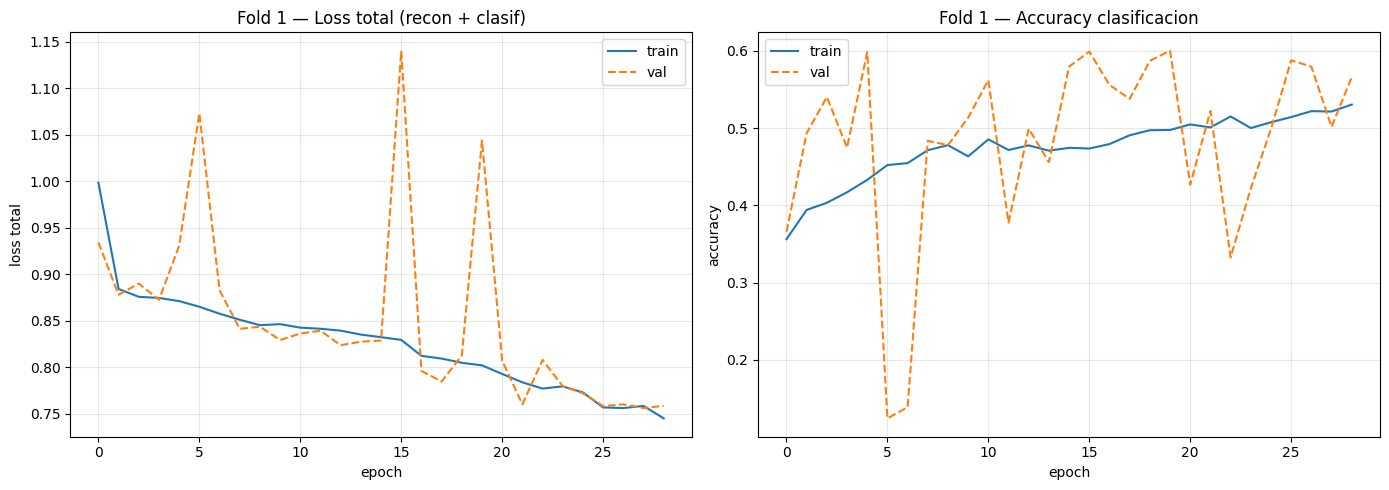


--- Evaluacion sobre test (2003 imgs) ---

--- SYMMETRY ---
              precision    recall  f1-score   support

      2_ejes     0.7453    0.5935    0.6608      1208
       1_eje     0.3549    0.2450    0.2899       604
  asimetrica     0.2179    0.7120    0.3337       191

    accuracy                         0.4998      2003
   macro avg     0.4394    0.5169    0.4282      2003
weighted avg     0.5773    0.4998    0.5178      2003



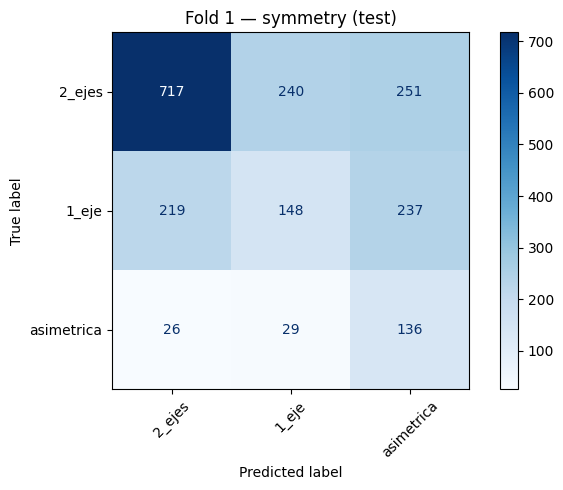

  Pesos guardados en: /home/marc/MARIADELMAR_EXPERIMENTS/STL_Symmetry_experimentos/UNet_STL/exp_2026-06-22_20-34_symmetry_5fold/fold_1/best_weights

FOLD 2/5  (U-Net symmetry autoencoder, desde cero)
  train=6409  val=1602  test(fijo)=2003
  Class weights: [0.558 1.082 3.519]

--- Entrenamiento U-Net autoencoder (LR=0.0005, max_epochs=60) ---
Epoch 1/60
401/401 - 257s - loss: 1.0041 - reconstruction_output_loss: 0.0397 - head_sym_loss: 1.2451 - head_sym_accuracy: 0.3286 - val_loss: 1.2941 - val_reconstruction_output_loss: 0.0318 - val_head_sym_loss: 1.6097 - val_head_sym_accuracy: 0.3084
Epoch 2/60
401/401 - 255s - loss: 0.8872 - reconstruction_output_loss: 0.0240 - head_sym_loss: 1.1030 - head_sym_accuracy: 0.3398 - val_loss: 0.8889 - val_reconstruction_output_loss: 0.0265 - val_head_sym_loss: 1.1044 - val_head_sym_accuracy: 0.1848
Epoch 3/60
401/401 - 259s - loss: 0.8794 - reconstruction_output_loss: 0.0231 - head_sym_loss: 1.0935 - head_sym_accuracy: 0.3742 - val_loss: 0.8868 - val_

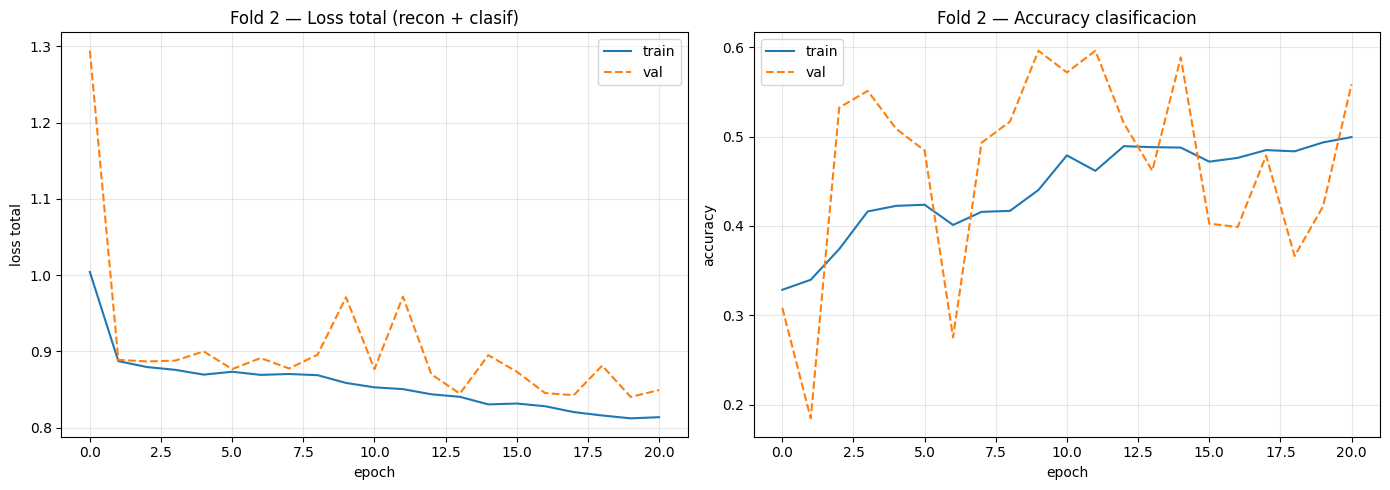


--- Evaluacion sobre test (2003 imgs) ---

--- SYMMETRY ---
              precision    recall  f1-score   support

      2_ejes     0.6902    0.6548    0.6720      1208
       1_eje     0.2939    0.1275    0.1778       604
  asimetrica     0.1748    0.5445    0.2646       191

    accuracy                         0.4853      2003
   macro avg     0.3863    0.4423    0.3715      2003
weighted avg     0.5216    0.4853    0.4842      2003



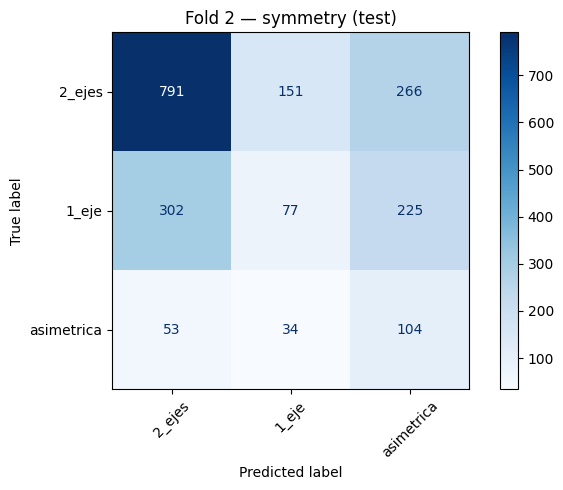

  Pesos guardados en: /home/marc/MARIADELMAR_EXPERIMENTS/STL_Symmetry_experimentos/UNet_STL/exp_2026-06-22_20-34_symmetry_5fold/fold_2/best_weights

FOLD 3/5  (U-Net symmetry autoencoder, desde cero)
  train=6409  val=1602  test(fijo)=2003
  Class weights: [0.558 1.082 3.519]

--- Entrenamiento U-Net autoencoder (LR=0.0005, max_epochs=60) ---
Epoch 1/60
401/401 - 260s - loss: 1.0335 - reconstruction_output_loss: 0.0302 - head_sym_loss: 1.2844 - head_sym_accuracy: 0.3484 - val_loss: 0.9048 - val_reconstruction_output_loss: 0.0264 - val_head_sym_loss: 1.1244 - val_head_sym_accuracy: 0.1573
Epoch 2/60
401/401 - 260s - loss: 0.8885 - reconstruction_output_loss: 0.0173 - head_sym_loss: 1.1063 - head_sym_accuracy: 0.3629 - val_loss: 0.8901 - val_reconstruction_output_loss: 0.0316 - val_head_sym_loss: 1.1047 - val_head_sym_accuracy: 0.4956
Epoch 3/60
401/401 - 260s - loss: 0.8788 - reconstruction_output_loss: 0.0146 - head_sym_loss: 1.0948 - head_sym_accuracy: 0.4068 - val_loss: 0.8990 - val_

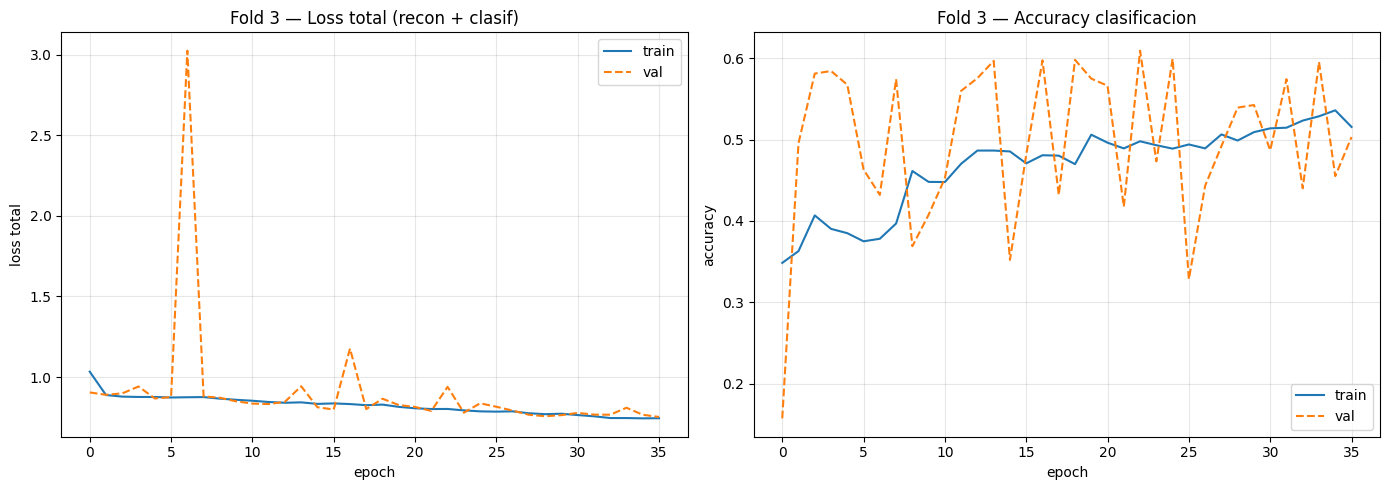


--- Evaluacion sobre test (2003 imgs) ---

--- SYMMETRY ---
              precision    recall  f1-score   support

      2_ejes     0.7303    0.6457    0.6854      1208
       1_eje     0.3688    0.2467    0.2956       604
  asimetrica     0.2279    0.6335    0.3352       191

    accuracy                         0.5242      2003
   macro avg     0.4423    0.5086    0.4387      2003
weighted avg     0.5734    0.5242    0.5345      2003



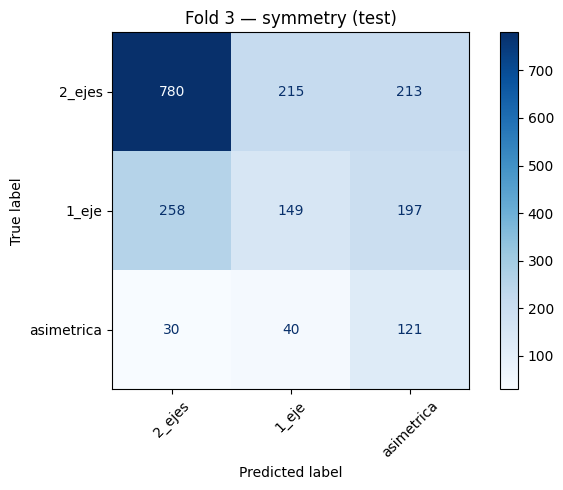

  Pesos guardados en: /home/marc/MARIADELMAR_EXPERIMENTS/STL_Symmetry_experimentos/UNet_STL/exp_2026-06-22_20-34_symmetry_5fold/fold_3/best_weights

FOLD 4/5  (U-Net symmetry autoencoder, desde cero)
  train=6409  val=1602  test(fijo)=2003
  Class weights: [0.558 1.082 3.525]

--- Entrenamiento U-Net autoencoder (LR=0.0005, max_epochs=60) ---
Epoch 1/60
401/401 - 258s - loss: 0.9833 - reconstruction_output_loss: 0.0300 - head_sym_loss: 1.2217 - head_sym_accuracy: 0.3604 - val_loss: 1.0919 - val_reconstruction_output_loss: 0.0535 - val_head_sym_loss: 1.3516 - val_head_sym_accuracy: 0.0955
Epoch 2/60
401/401 - 258s - loss: 0.8832 - reconstruction_output_loss: 0.0129 - head_sym_loss: 1.1008 - head_sym_accuracy: 0.3629 - val_loss: 1.0244 - val_reconstruction_output_loss: 0.0334 - val_head_sym_loss: 1.2721 - val_head_sym_accuracy: 0.5293
Epoch 3/60
401/401 - 258s - loss: 0.8697 - reconstruction_output_loss: 0.0116 - head_sym_loss: 1.0842 - head_sym_accuracy: 0.4216 - val_loss: 0.8877 - val_

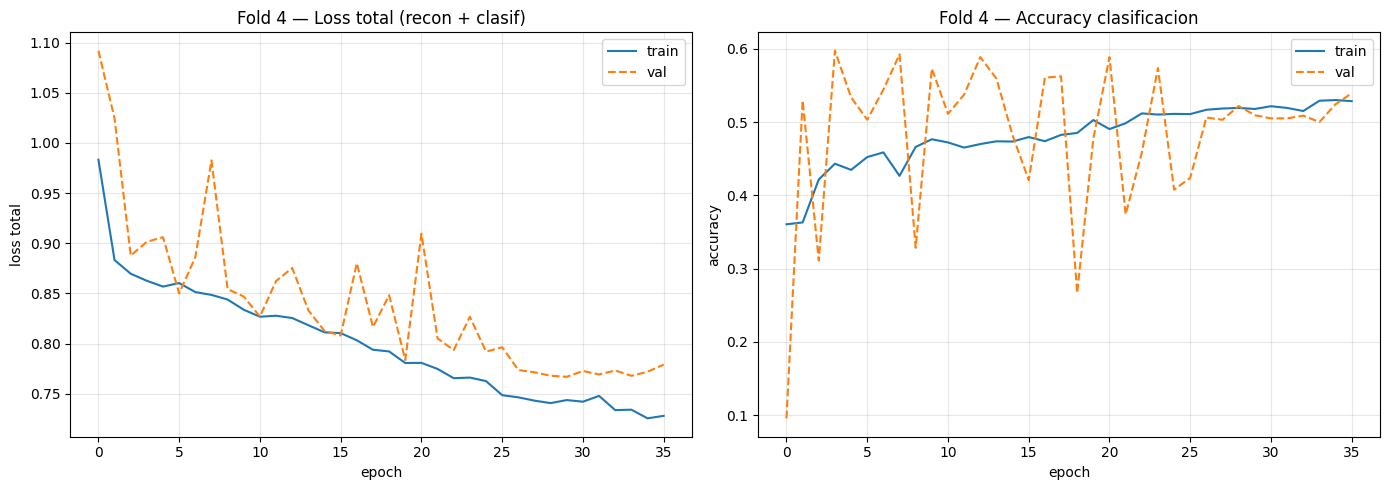


--- Evaluacion sobre test (2003 imgs) ---

--- SYMMETRY ---
              precision    recall  f1-score   support

      2_ejes     0.7550    0.6200    0.6809      1208
       1_eje     0.3541    0.2450    0.2896       604
  asimetrica     0.2395    0.7435    0.3622       191

    accuracy                         0.5187      2003
   macro avg     0.4495    0.5362    0.4443      2003
weighted avg     0.5850    0.5187    0.5325      2003



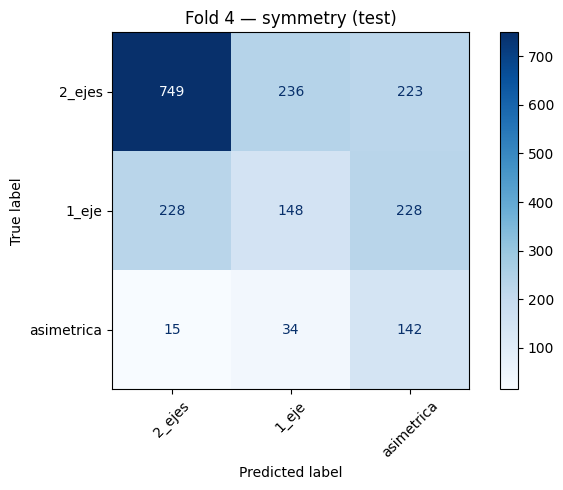

  Pesos guardados en: /home/marc/MARIADELMAR_EXPERIMENTS/STL_Symmetry_experimentos/UNet_STL/exp_2026-06-22_20-34_symmetry_5fold/fold_4/best_weights

FOLD 5/5  (U-Net symmetry autoencoder, desde cero)
  train=6409  val=1602  test(fijo)=2003
  Class weights: [0.558 1.082 3.525]

--- Entrenamiento U-Net autoencoder (LR=0.0005, max_epochs=60) ---
Epoch 1/60
401/401 - 259s - loss: 1.0589 - reconstruction_output_loss: 0.0327 - head_sym_loss: 1.3155 - head_sym_accuracy: 0.3506 - val_loss: 0.9018 - val_reconstruction_output_loss: 0.0211 - val_head_sym_loss: 1.1220 - val_head_sym_accuracy: 0.2260
Epoch 2/60
401/401 - 258s - loss: 0.8869 - reconstruction_output_loss: 0.0140 - head_sym_loss: 1.1051 - head_sym_accuracy: 0.3621 - val_loss: 0.9339 - val_reconstruction_output_loss: 0.0166 - val_head_sym_loss: 1.1632 - val_head_sym_accuracy: 0.3533
Epoch 3/60
401/401 - 258s - loss: 0.8844 - reconstruction_output_loss: 0.0074 - head_sym_loss: 1.1037 - head_sym_accuracy: 0.3534 - val_loss: 0.9941 - val_

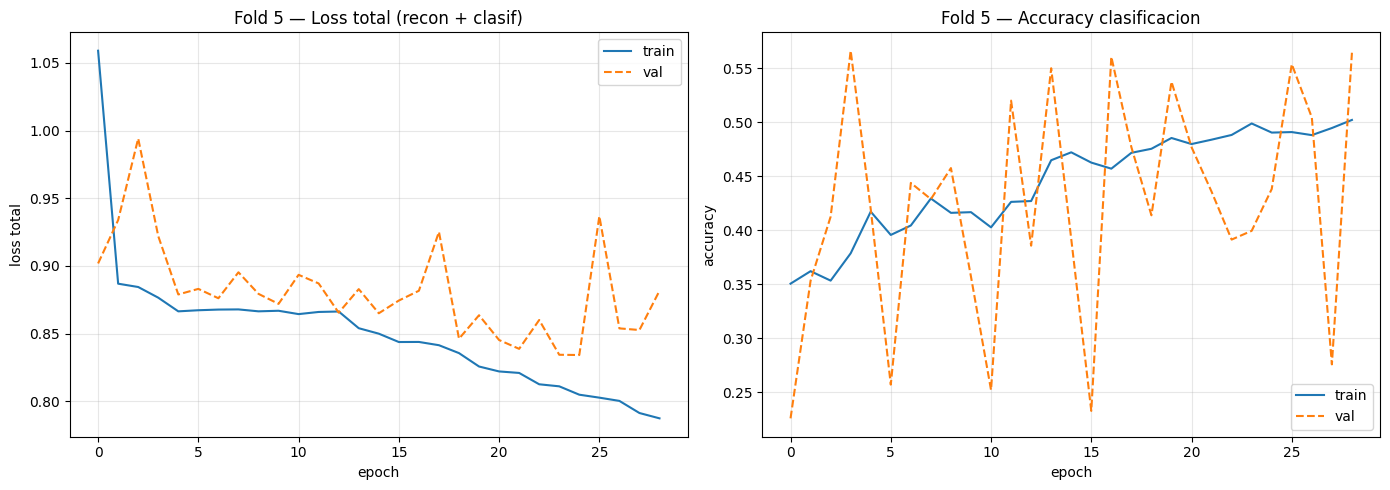


--- Evaluacion sobre test (2003 imgs) ---

--- SYMMETRY ---
              precision    recall  f1-score   support

      2_ejes     0.7144    0.5488    0.6208      1208
       1_eje     0.3199    0.1705    0.2225       604
  asimetrica     0.1660    0.6545    0.2648       191

    accuracy                         0.4448      2003
   macro avg     0.4001    0.4579    0.3694      2003
weighted avg     0.5432    0.4448    0.4667      2003



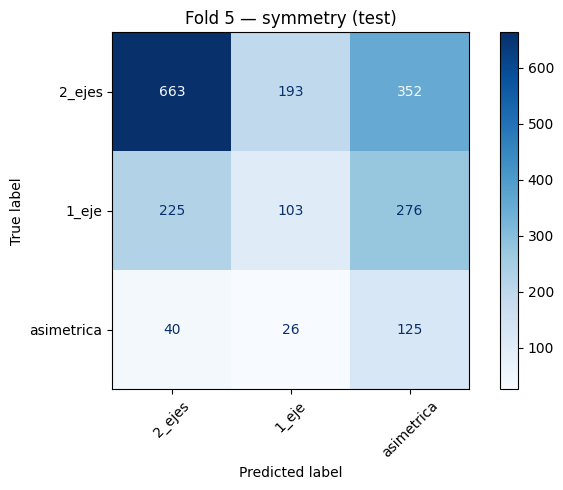

  Pesos guardados en: /home/marc/MARIADELMAR_EXPERIMENTS/STL_Symmetry_experimentos/UNet_STL/exp_2026-06-22_20-34_symmetry_5fold/fold_5/best_weights

*** Experimento STL UNet symmetry completo en 650.8 min ***

RESUMEN ENTRE 5 FOLDS
                                 mean       median          std
time_train_s              7784.640000  7434.100000  1614.609746
time_predict_s              22.580000    22.570000     0.129808
epochs_trained              30.200000    29.000000     6.220932
symmetry_acc                 0.494558     0.499750     0.031816
symmetry_balanced_acc        0.492376     0.508631     0.040248
symmetry_precision_macro     0.423534     0.439396     0.028353
symmetry_recall_macro        0.492376     0.508631     0.040248
symmetry_f1_macro            0.410405     0.428161     0.036955
symmetry_f1_weighted         0.507140     0.517790     0.030275
symmetry_kappa               0.169830     0.190352     0.041269
symmetry_auc_macro           0.651625     0.669271     0.041106


In [8]:
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

all_fold_metrics = []
histories        = []   # UNet: una sola historia por fold (sin warmup+FT separados)

t_exp_start = time.time()

for fold_idx, (train_idx, val_idx) in enumerate(
        skf.split(np.zeros(len(df_trainval)), y_trainval_int), 1):
    fold_dir = EXP_DIR / f"fold_{fold_idx}"
    result   = train_one_fold(fold_idx, train_idx, val_idx, fold_dir)
    all_fold_metrics.append(result["metrics"])
    histories.append(result["history"])
    del result
    tf.keras.backend.clear_session()

t_exp_total = time.time() - t_exp_start

print(f"\n{'='*70}")
print(f"*** Experimento STL UNet {TASK_NAME} completo en {t_exp_total/60:.1f} min ***")
print(f"{'='*70}")

df_metrics = pd.DataFrame(all_fold_metrics)
df_metrics.to_csv(EXP_DIR / "all_folds_metrics.csv", index=False)

numeric = [c for c in df_metrics.columns
           if c != "fold" and pd.api.types.is_numeric_dtype(df_metrics[c])]
summary = df_metrics[numeric].agg(["mean", "median", "std"]).T
summary.columns = ["mean", "median", "std"]
summary["mean±std"] = summary.apply(
    lambda r: f"{r['mean']:.4f} ± {r['std']:.4f}", axis=1)
summary.to_csv(EXP_DIR / "summary_mean_median_std.csv")

print("\n" + "="*70)
print(f"RESUMEN ENTRE {N_FOLDS} FOLDS")
print("="*70)
print(summary[["mean", "median", "std"]])
print(f"\nGuardado en: {EXP_DIR}")

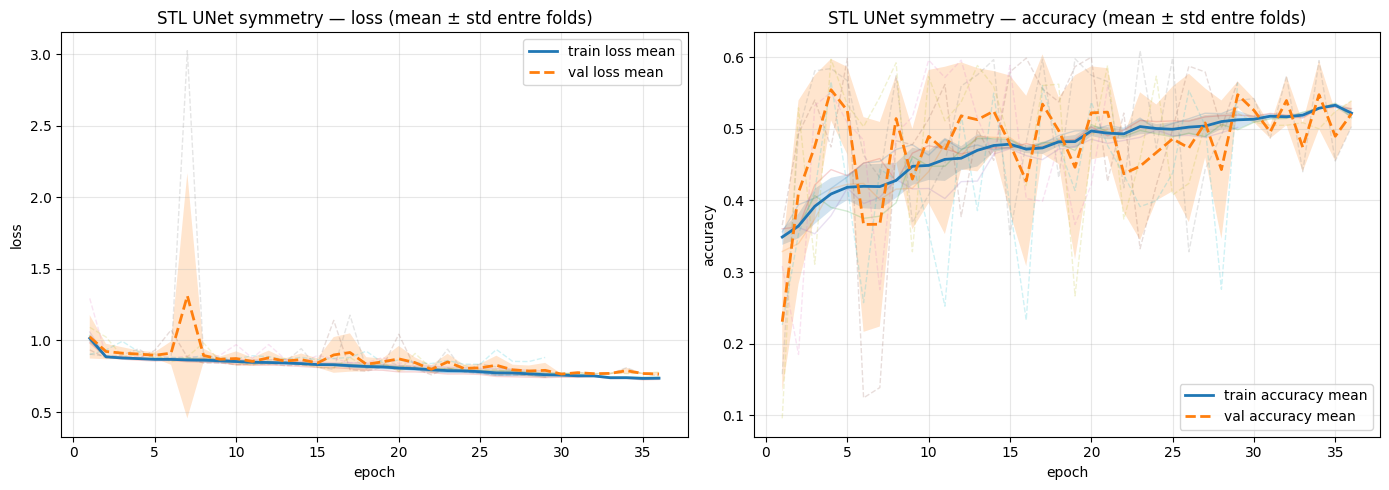

In [9]:
def _hist_to_dict(h):
    return h.history if hasattr(h, "history") else h

def _pad_to_len(arr, max_len):
    arr = np.asarray(arr, dtype=np.float32)
    out = np.full((max_len,), np.nan, dtype=np.float32)
    out[:min(len(arr), max_len)] = arr[:min(len(arr), max_len)]
    return out

def _stack_metric(histories, key):
    hs      = [_hist_to_dict(h) for h in histories]
    lens    = [len(h.get(key, [])) for h in hs]
    max_len = max(lens) if lens else 0
    if max_len == 0:
        return np.empty((0, 0), dtype=np.float32), 0
    stacked = np.vstack([_pad_to_len(h.get(key, []), max_len)
                         for h in hs]).astype(np.float32)
    return stacked, max_len


plots_dir = EXP_DIR / "training_plots_cv"
plots_dir.mkdir(exist_ok=True)

# Loss total + accuracy de clasificacion (mean +/- std entre folds)
keys = {"loss": ("loss", "val_loss"),
        "accuracy": ("head_sym_accuracy", "val_head_sym_accuracy")}
stacked_dict, max_len = {}, 0
for name, (k_tr, k_va) in keys.items():
    tr, ml = _stack_metric(histories, k_tr)
    va, _  = _stack_metric(histories, k_va)
    stacked_dict[name] = (tr, va)
    max_len = max(max_len, ml)
epochs = np.arange(1, max_len + 1)

plt.figure(figsize=(14, 5))
for i, name in enumerate(["loss", "accuracy"], 1):
    tr, va = stacked_dict[name]
    m_tr = np.nanmean(tr, axis=0); s_tr = np.nanstd(tr, axis=0)
    m_va = np.nanmean(va, axis=0); s_va = np.nanstd(va, axis=0)
    plt.subplot(1, 2, i)
    for f in range(tr.shape[0]):
        plt.plot(epochs, tr[f], alpha=0.2, linewidth=1)
    for f in range(va.shape[0]):
        plt.plot(epochs, va[f], alpha=0.2, linewidth=1, linestyle="--")
    plt.plot(epochs, m_tr, linewidth=2, label=f"train {name} mean")
    plt.fill_between(epochs, m_tr - s_tr, m_tr + s_tr, alpha=0.2)
    plt.plot(epochs, m_va, linewidth=2, linestyle="--", label=f"val {name} mean")
    plt.fill_between(epochs, m_va - s_va, m_va + s_va, alpha=0.2)
    plt.title(f"STL UNet {TASK_NAME} - {name} (mean ± std entre folds)")
    plt.xlabel("epoch"); plt.ylabel(name)
    plt.grid(True, alpha=0.3); plt.legend()
plt.tight_layout()
plt.savefig(plots_dir / "training_cv_mean_std.png", dpi=300)
plt.show()

Usando fold 4  (symmetry_balanced_acc=0.5362)
Pesos cargados desde /home/marc/MARIADELMAR_EXPERIMENTS/STL_Symmetry_experimentos/UNet_STL/exp_2026-06-22_20-34_symmetry_5fold/fold_4/best_weights

Recomputando predicciones del fold seleccionado...

=== GradCAM — Tarea: SYMMETRY (matriz por clase con máscaras) ===
  Guardado: /home/marc/MARIADELMAR_EXPERIMENTS/STL_Symmetry_experimentos/UNet_STL/exp_2026-06-22_20-34_symmetry_5fold/gradcam/gradcam_symmetry_by_class.png


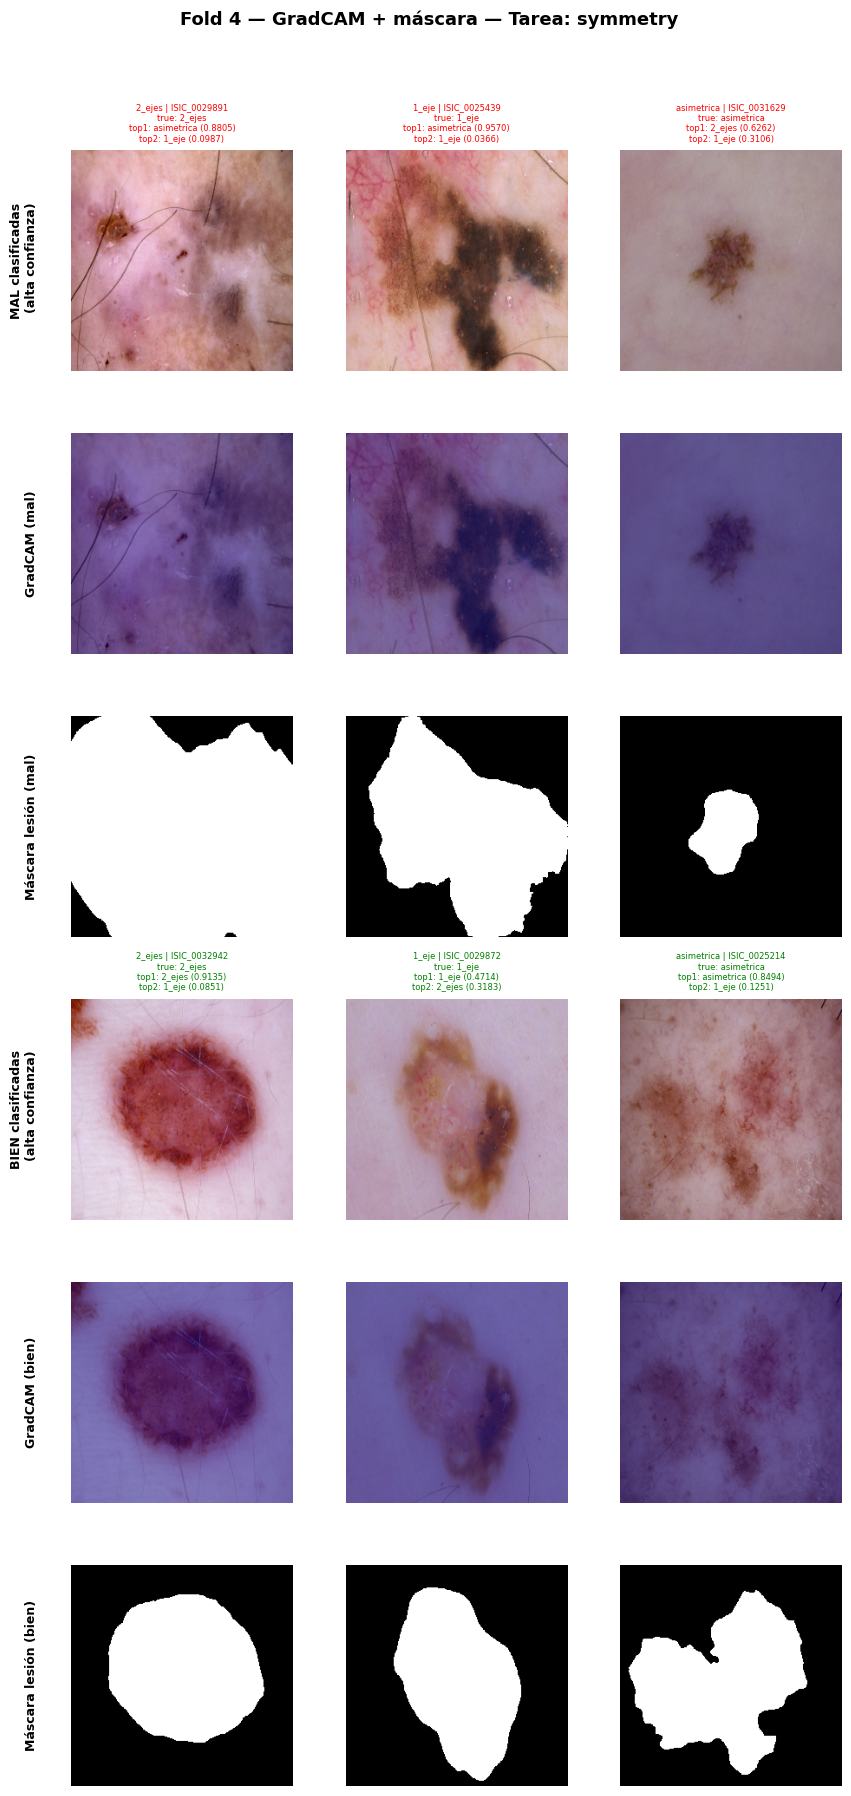


Imágenes GradCAM guardadas en: /home/marc/MARIADELMAR_EXPERIMENTS/STL_Symmetry_experimentos/UNet_STL/exp_2026-06-22_20-34_symmetry_5fold/gradcam


In [10]:
import cv2

SEG_MASKS_PATH = "/home/marc/MARIADELMAR_EXPERIMENTS/dataverse_files/binary_seg/HAM10000_segmentations_lesion_tschandl"

# Mejor fold
best_metric_col = f"{TASK_NAME}_balanced_acc"
best_fold_idx   = int(df_metrics[best_metric_col].idxmax()) + 1
print(f"Usando fold {best_fold_idx}  "
      f"({best_metric_col}={df_metrics[best_metric_col].max():.4f})")

fold_dir_best = EXP_DIR / f"fold_{best_fold_idx}"
weights_path  = fold_dir_best / "best_weights"

# Reconstruir modelo y cargar pesos
backbone_gc, _ = build_model()

for imgs, _ in test_ds.take(1):
    _ = backbone_gc(imgs[:1], training=False)

if (fold_dir_best / "best_weights.index").exists():
    backbone_gc.load_weights(str(weights_path))
    print(f"Pesos cargados desde {weights_path}")
else:
    print(f"[AVISO] No se encontro {weights_path}.index")


def make_gradcam_heatmap(img_array, model, class_idx):
    
    last_conv_layer = "bottleneck_conv"

    grad_model = tf.keras.Model(
        inputs=model.inputs,
        outputs=[
            model.get_layer(last_conv_layer).output,
            model.get_layer("head_sym").output,
        ]
    )

    gap_layer    = model.get_layer("gap")
    shared_dense = model.get_layer("shared_dense")
    shared_drop  = model.get_layer("shared_dropout")
    head_sym     = model.get_layer("head_sym")

    with tf.GradientTape() as tape:
        conv_outputs, _ = grad_model(img_array, training=False)
        tape.watch(conv_outputs)
        # Forward desde gap hasta la cabeza (Dense(256) + Dropout(0.3))
        x     = gap_layer(conv_outputs)
        x     = shared_dense(x)
        x     = shared_drop(x, training=False)
        preds = head_sym(x)
        loss  = preds[:, class_idx]

    grads        = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    heatmap      = conv_outputs[0] @ pooled_grads[..., tf.newaxis]
    heatmap      = tf.squeeze(heatmap)
    heatmap      = tf.maximum(heatmap, 0)
    heatmap      = heatmap / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()


def overlay_heatmap(img_orig, heatmap, alpha=0.45):
    heatmap_r = cv2.resize(heatmap, (img_orig.shape[1], img_orig.shape[0]))
    colored   = cv2.applyColorMap((heatmap_r * 255).astype(np.uint8), cv2.COLORMAP_JET)
    colored   = cv2.cvtColor(colored, cv2.COLOR_BGR2RGB)
    return (alpha * colored + (1 - alpha) * img_orig).astype(np.uint8)


def load_img_for_gradcam(filepath):
    raw      = tf.io.read_file(filepath)
    raw      = tf.image.decode_image(raw, channels=3, expand_animations=False)
    raw      = tf.image.resize(raw, IMG_SIZE)
    img_orig = raw.numpy().astype(np.uint8)
    img_pre  = tf.cast(raw, tf.float32) / 255.0
    return img_orig, tf.expand_dims(img_pre, 0)


def load_lesion_mask(image_id):
    # Carga la mascara binaria de la lesion y la redimensiona a IMG_SIZE.
    mask_path = os.path.join(SEG_MASKS_PATH, f"{image_id}_segmentation.png")
    if not os.path.exists(mask_path):
        return None
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    if mask is None:
        return None
    mask = cv2.resize(mask, IMG_SIZE, interpolation=cv2.INTER_NEAREST)
    return mask


def plot_gradcam_by_class(df_test, y_true_int, y_pred_int, y_pred_proba,
                          backbone_model, class_names,
                          fold_label="", save_dir=None):
    # Matriz 6 x n_clases:
    #   fila 1: MAL clasificadas (original)   fila 4: BIEN clasificadas (original)
    #   fila 2: GradCAM (mal)                 fila 5: GradCAM (bien)
    #   fila 3: mascara lesion (mal)          fila 6: mascara lesion (bien)
    n_cls = len(class_names)
    fig, axes = plt.subplots(6, n_cls, figsize=(3 * n_cls, 18))
    if n_cls == 1:
        axes = axes[:, np.newaxis]

    fig.suptitle(f"{fold_label} GradCAM + máscara - Tarea: {TASK_NAME}",
                 fontsize=13, fontweight="bold", y=0.995)

    for ci, cname in enumerate(class_names):
        # MAL clasificadas
        mask_bad = (y_true_int == ci) & (y_pred_int != ci)
        idx_bad  = np.where(mask_bad)[0]
        if len(idx_bad) > 0:
            confidences = y_pred_proba[idx_bad, y_pred_int[idx_bad]]
            best        = idx_bad[np.argmax(confidences)]
            top2_idx    = np.argsort(y_pred_proba[best])[::-1][:2]
            top1_cls    = class_names[top2_idx[0]]
            top2_cls    = class_names[top2_idx[1]]
            top1_prob   = y_pred_proba[best, top2_idx[0]]
            top2_prob   = y_pred_proba[best, top2_idx[1]]

            filepath          = df_test.iloc[best]["filepath"]
            image_id          = df_test.iloc[best]["image_id"]
            img_orig, img_pre = load_img_for_gradcam(filepath)
            heatmap  = make_gradcam_heatmap(img_pre, backbone_model, class_idx=int(top2_idx[0]))
            overlay  = overlay_heatmap(img_orig, heatmap)
            seg_mask = load_lesion_mask(image_id)

            axes[0, ci].imshow(img_orig)
            axes[0, ci].set_title(
                f"{cname} | {image_id}\ntrue: {cname}\n"
                f"top1: {top1_cls} ({top1_prob:.4f})\n"
                f"top2: {top2_cls} ({top2_prob:.4f})",
                fontsize=6, color="red")
            axes[1, ci].imshow(overlay)
            if seg_mask is not None:
                axes[2, ci].imshow(seg_mask, cmap="gray")
            else:
                axes[2, ci].text(0.5, 0.5, "máscara\nno disponible",
                                 ha="center", va="center", fontsize=7)
        else:
            for r in range(3):
                axes[r, ci].text(0.5, 0.5, f"{cname}\nNo hay\nmalas",
                                 ha="center", va="center", fontsize=8)

        # BIEN clasificadas
        mask_good = (y_true_int == ci) & (y_pred_int == ci)
        idx_good  = np.where(mask_good)[0]
        if len(idx_good) > 0:
            confidences = y_pred_proba[idx_good, ci]
            best        = idx_good[np.argmax(confidences)]
            top2_idx    = np.argsort(y_pred_proba[best])[::-1][:2]
            top1_cls    = class_names[top2_idx[0]]
            top2_cls    = class_names[top2_idx[1]]
            top1_prob   = y_pred_proba[best, top2_idx[0]]
            top2_prob   = y_pred_proba[best, top2_idx[1]]

            filepath          = df_test.iloc[best]["filepath"]
            image_id          = df_test.iloc[best]["image_id"]
            img_orig, img_pre = load_img_for_gradcam(filepath)
            heatmap  = make_gradcam_heatmap(img_pre, backbone_model, class_idx=int(ci))
            overlay  = overlay_heatmap(img_orig, heatmap)
            seg_mask = load_lesion_mask(image_id)

            axes[3, ci].imshow(img_orig)
            axes[3, ci].set_title(
                f"{cname} | {image_id}\ntrue: {cname}\n"
                f"top1: {top1_cls} ({top1_prob:.4f})\n"
                f"top2: {top2_cls} ({top2_prob:.4f})",
                fontsize=6, color="green")
            axes[4, ci].imshow(overlay)
            if seg_mask is not None:
                axes[5, ci].imshow(seg_mask, cmap="gray")
            else:
                axes[5, ci].text(0.5, 0.5, "máscara\nno disponible",
                                 ha="center", va="center", fontsize=7)
        else:
            for r in range(3, 6):
                axes[r, ci].text(0.5, 0.5, f"{cname}\nNo hay\nbuenas",
                                 ha="center", va="center", fontsize=8)

        for r in range(6):
            axes[r, ci].axis("off")

    row_labels = [
        "MAL clasificadas\n(alta confianza)",
        "GradCAM (mal)",
        "Máscara lesión (mal)",
        "BIEN clasificadas\n(alta confianza)",
        "GradCAM (bien)",
        "Máscara lesión (bien)",
    ]
    for r, label in enumerate(row_labels):
        axes[r, 0].text(-0.15, 0.5, label, transform=axes[r, 0].transAxes,
                        fontsize=9, rotation=90, va="center", ha="right",
                        fontweight="bold")

    plt.tight_layout(rect=[0, 0, 1, 0.97])
    if save_dir:
        out = Path(save_dir) / f"gradcam_{TASK_NAME}_by_class.png"
        plt.savefig(out, dpi=150, bbox_inches="tight")
        print(f"  Guardado: {out}")
    plt.show()


# Predicciones del fold elegido
print("\nRecomputando predicciones del fold seleccionado...")
preds_gc        = backbone_gc.predict(test_ds, verbose=0)
y_pred_proba_gc = preds_gc[1]   # [0]=reconstruccion, [1]=clasificacion
y_pred_int_gc   = np.argmax(y_pred_proba_gc, axis=1)

gradcam_dir = EXP_DIR / "gradcam"
gradcam_dir.mkdir(exist_ok=True)
fold_label  = f"Fold {best_fold_idx}"

print(f"\n=== GradCAM - Tarea: {TASK_NAME.upper()} (matriz por clase con máscaras) ===")
plot_gradcam_by_class(
    df_test, y_test_int, y_pred_int_gc, y_pred_proba_gc,
    backbone_gc, class_names=class_names,
    fold_label=fold_label, save_dir=str(gradcam_dir))

print(f"\nImágenes GradCAM guardadas en: {gradcam_dir.resolve()}")

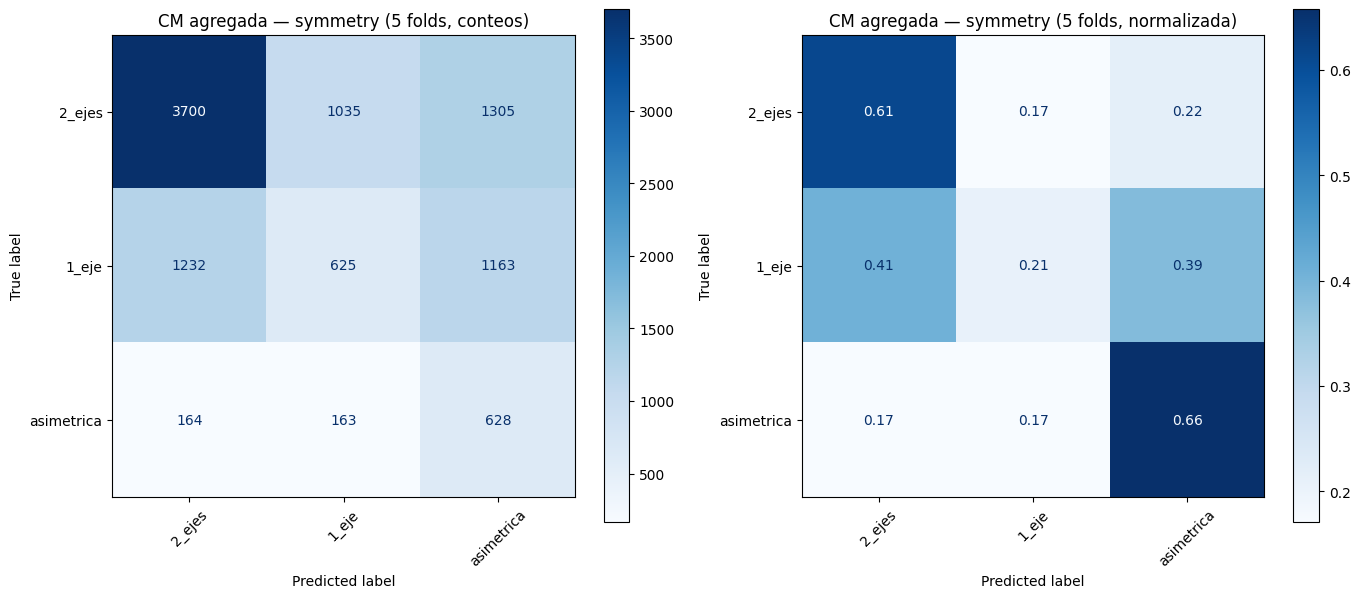


Matriz agregada guardada en /home/marc/MARIADELMAR_EXPERIMENTS/STL_Symmetry_experimentos/UNet_STL/exp_2026-06-22_20-34_symmetry_5fold


In [11]:
# Matriz de confusion agregada entre folds
cms = []
for k in range(1, N_FOLDS + 1):
    cm_path = EXP_DIR / f"fold_{k}" / f"confusion_matrix_{TASK_NAME}.npy"
    if cm_path.exists():
        cms.append(np.load(cm_path))

if cms:
    cm_sum  = np.sum(cms, axis=0)
    cm_norm = cm_sum.astype(float) / cm_sum.sum(axis=1, keepdims=True).clip(min=1)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    ConfusionMatrixDisplay(cm_sum, display_labels=class_names).plot(
        ax=axes[0], cmap="Blues", xticks_rotation=45, colorbar=True, values_format="d")
    axes[0].set_title(f"CM agregada - {TASK_NAME} ({N_FOLDS} folds, conteos)")

    ConfusionMatrixDisplay(cm_norm, display_labels=class_names).plot(
        ax=axes[1], cmap="Blues", xticks_rotation=45, colorbar=True, values_format=".2f")
    axes[1].set_title(f"CM agregada - {TASK_NAME} ({N_FOLDS} folds, normalizada)")

    plt.tight_layout()
    plt.savefig(EXP_DIR / f"confusion_matrix_{TASK_NAME}_aggregated.png", dpi=120)
    plt.show()
    print(f"\nMatriz agregada guardada en {EXP_DIR}")
else:
    print("[WARN] No se encontraron CMs guardadas.")

In [12]:
def build_final_pdf():
    pdf_path    = EXP_DIR / f"FINAL_REPORT_UNet_STL_{TASK_NAME}.pdf"
    plots_dir   = EXP_DIR / "training_plots_cv"
    gradcam_dir = EXP_DIR / "gradcam"

    with PdfPages(pdf_path) as pdf:

        # Portada
        fig = plt.figure(figsize=(11, 8.5))
        fig.text(0.5, 0.92, f"STL UNet {TASK_NAME} (autoencoder, sin transfer learning) - Reporte final",
                 ha="center", fontsize=18, fontweight="bold")
        fig.text(0.5, 0.87, f"U-Net completa (encoder + decoder)  |  K={N_FOLDS} folds  |  Single-task",
                 ha="center", fontsize=13, style="italic")
        fig.text(0.5, 0.83, EXP_DIR.name,
                 ha="center", fontsize=9, family="monospace")

        info  = "Arquitectura: U-Net completa (encoder + decoder), entrenada como autoencoder + 1 cabeza STL\n\n"
        info += "Encoder: Conv(64) -> Conv(128) -> Conv(256) -> Conv(512)\n"
        info += "Bottleneck: Conv(1024) x 2\n"
        info += "Decoder: 4 bloques con skip connections (512 -> 256 -> 128 -> 64) -> reconstruccion 256x256x3\n"
        info += "Cabeza compartida: GAP(bottleneck) -> Dense(256, relu) -> Dropout(0.3)\n"
        info += "  (identica a la del MTL UNet final para comparabilidad)\n\n"
        info += "Tarea:\n"
        info += f"  - Symmetry classification  ({NUM_CLASSES} clases): {', '.join(class_names)}\n\n"
        info += "Configuracion de entrenamiento:\n"
        info += f"  - Una sola fase (todo trainable desde inicio, sin transfer learning)\n"
        info += f"  - LR inicial: {LR_INIT}  |  epochs max: {EPOCHS}\n"
        info += f"  - Early stopping patience: 7  |  ReduceLR patience: 3\n"
        info += f"  - Batch size: {BATCH_SIZE}, image size: {IMG_SIZE[0]}x{IMG_SIZE[1]}\n\n"
        info += f"Loss: MSE reconstruccion (peso 0.2) + categorical_crossentropy clasificacion (peso 0.8)\n"
        info += f"Class weights balanceados (via sample_weight) aplicados a la clasificacion\n\n"
        info += f"Dataset:\n"
        info += f"  - train+val (CV): {len(df_trainval)} imagenes\n"
        info += f"  - test (fijo):    {len(df_test)} imagenes\n\n"
        info += f"Tiempo total experimento: {t_exp_total/60:.1f} min"

        fig.text(0.08, 0.75, info, fontsize=9, family="monospace", va="top")
        plt.axis("off")
        pdf.savefig(fig); plt.close(fig)

        # Resumen ejecutivo
        fig, ax = plt.subplots(figsize=(12, 6))
        ax.axis("off")
        ax.set_title(f"Resumen ejecutivo - métricas de clasificación ({N_FOLDS} folds)",
                     fontsize=14, fontweight="bold", pad=20)

        task_metrics_list = [
            (f"{TASK_NAME}_acc",             "Accuracy"),
            (f"{TASK_NAME}_balanced_acc",    "Balanced Acc"),
            (f"{TASK_NAME}_precision_macro", "Precision macro"),
            (f"{TASK_NAME}_recall_macro",    "Recall macro"),
            (f"{TASK_NAME}_f1_macro",        "F1 macro"),
            (f"{TASK_NAME}_auc_macro",       "AUC macro"),
            (f"{TASK_NAME}_kappa",           "Kappa"),
        ]

        rows       = []
        row_colors = []
        rows.append([f"Symmetry ({NUM_CLASSES} clases)", "", "", ""])
        row_colors.append(["#d9e1f2"] * 4)
        for metric_key, label in task_metrics_list:
            if metric_key in summary.index:
                mean   = summary.loc[metric_key, "mean"]
                median = summary.loc[metric_key, "median"]
                std    = summary.loc[metric_key, "std"]
                rows.append([f"  {label}",
                             f"{mean:.4f}", f"{median:.4f}", f"{std:.4f}"])
                row_colors.append(["white"] * 4)

        tbl = ax.table(
            cellText=rows,
            colLabels=["Métrica", "Media", "Mediana", "Desv. típica"],
            loc="center", cellLoc="left",
            cellColours=row_colors,
            colColours=["#305496"] * 4,
        )
        tbl.auto_set_font_size(False); tbl.set_fontsize(10); tbl.scale(1, 1.8)
        for j in range(4):
            tbl[(0, j)].set_text_props(color="white", fontweight="bold")
        pdf.savefig(fig, bbox_inches="tight"); plt.close(fig)

        # Tabla completa mean/median/std
        fig, ax = plt.subplots(figsize=(13, 8.5))
        ax.axis("off")
        ax.set_title(f"Resumen completo entre folds (K={N_FOLDS}) - mean / median / std",
                     fontsize=14, fontweight="bold", pad=20)
        tbl = ax.table(
            cellText=[[i, f"{r['mean']:.4f}", f"{r['median']:.4f}", f"{r['std']:.4f}"]
                      for i, r in summary.iterrows()],
            colLabels=["métrica", "mean", "median", "std"],
            loc="center", cellLoc="left",
        )
        tbl.auto_set_font_size(False); tbl.set_fontsize(7); tbl.scale(1, 1.4)
        pdf.savefig(fig); plt.close(fig)

        # Tabla metricas por fold
        fig, ax = plt.subplots(figsize=(14, 8.5))
        ax.axis("off")
        ax.set_title(f"Métricas por fold - STL {TASK_NAME}",
                     fontsize=14, fontweight="bold", pad=20)
        cols = [
            "fold",
            f"{TASK_NAME}_acc", f"{TASK_NAME}_balanced_acc",
            f"{TASK_NAME}_precision_macro", f"{TASK_NAME}_recall_macro",
            f"{TASK_NAME}_f1_macro", f"{TASK_NAME}_auc_macro", f"{TASK_NAME}_kappa",
            "epochs_trained", "time_train_s",
        ]
        df_show = df_metrics[[c for c in cols if c in df_metrics.columns]].copy()
        for c in df_show.columns:
            if c != "fold":
                df_show[c] = df_show[c].round(4)
        tbl = ax.table(
            cellText=df_show.values.tolist(),
            colLabels=df_show.columns.tolist(),
            loc="center", cellLoc="center",
        )
        tbl.auto_set_font_size(False); tbl.set_fontsize(7); tbl.scale(1, 1.4)
        pdf.savefig(fig); plt.close(fig)

        # Curvas de entrenamiento
        for fname, title in [
            ("training_cv_mean_std.png", "Loss/Acc total (mean ± std)"),
        ]:
            p = plots_dir / fname
            if p.exists():
                fig = plt.figure(figsize=(14, 7))
                plt.imshow(plt.imread(str(p))); plt.axis("off")
                plt.title(title, fontsize=12, fontweight="bold")
                pdf.savefig(fig); plt.close(fig)

        # Matriz de confusion agregada
        p = EXP_DIR / f"confusion_matrix_{TASK_NAME}_aggregated.png"
        if p.exists():
            fig = plt.figure(figsize=(14, 6))
            plt.imshow(plt.imread(str(p))); plt.axis("off")
            plt.title(f"Matriz de confusión agregada - {TASK_NAME} ({NUM_CLASSES} clases)",
                      fontsize=12, fontweight="bold")
            pdf.savefig(fig, bbox_inches="tight"); plt.close(fig)

        # GradCAM por clase
        p = gradcam_dir / f"gradcam_{TASK_NAME}_by_class.png"
        if p.exists():
            img_data = plt.imread(str(p))
            h, w     = img_data.shape[:2]
            fig = plt.figure(figsize=(11, 11 * h / w))
            plt.imshow(img_data); plt.axis("off")
            plt.title(f"GradCAM buenas/malas por clase - {TASK_NAME} ({NUM_CLASSES} clases)",
                      fontsize=12, fontweight="bold")
            pdf.savefig(fig, bbox_inches="tight"); plt.close(fig)

        # Detalle por fold
        for k in range(1, N_FOLDS + 1):
            fd = EXP_DIR / f"fold_{k}"

            p = fd / "training_curves.png"
            if p.exists():
                fig = plt.figure(figsize=(14, 6))
                plt.imshow(plt.imread(str(p))); plt.axis("off")
                plt.title(f"Fold {k} - Curvas de entrenamiento",
                          fontsize=12, fontweight="bold")
                pdf.savefig(fig); plt.close(fig)

            p = fd / f"confusion_matrix_{TASK_NAME}.png"
            if p.exists():
                fig = plt.figure(figsize=(10, 7))
                plt.imshow(plt.imread(str(p))); plt.axis("off")
                plt.title(f"Fold {k} - Matriz confusión - {TASK_NAME} ({NUM_CLASSES} clases)",
                          fontsize=11, fontweight="bold")
                pdf.savefig(fig); plt.close(fig)

            rpt = fd / f"classification_report_{TASK_NAME}.txt"
            if rpt.exists():
                fig = plt.figure(figsize=(11, 8.5)); plt.axis("off")
                plt.title(f"Fold {k} - Classification report - {TASK_NAME}",
                          fontsize=11, fontweight="bold", loc="left")
                plt.text(0.05, 0.95, rpt.read_text(),
                         fontsize=10, family="monospace", va="top")
                pdf.savefig(fig); plt.close(fig)

    print(f" PDF guardado en: {pdf_path.resolve()}")
    return pdf_path


_ = build_final_pdf()

 PDF guardado en: /home/marc/MARIADELMAR_EXPERIMENTS/STL_Symmetry_experimentos/UNet_STL/exp_2026-06-22_20-34_symmetry_5fold/FINAL_REPORT_UNet_STL_symmetry.pdf
